In [1]:
import socket
import subprocess

def check_postgres():
    # 1. Check if the default PostgreSQL port (5432) is open locally
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(1.0)
    port_open = s.connect_ex(('127.0.0.1', 5432)) == 0
    s.close()

    # 2. Check system processes for running Postgres instances
    try:
        ps_out = subprocess.check_output(["ps", "-ef"]).decode("utf-8")
        is_process_running = "postgres" in ps_out or "postmaster" in ps_out
    except Exception:
        is_process_running = False

    # 3. Check CLI utilities
    try:
        pg_ready = subprocess.run(["pg_isready"], capture_output=True, text=True)
        ready_status = pg_ready.stdout.strip()
    except FileNotFoundError:
        ready_status = "CLI tool 'pg_isready' not installed"

    print("================ POSTGRES STATUS ================")
    print(f"Port 5432 Open:      {port_open}")
    print(f"Process Running:     {is_process_running}")
    print(f"Connection Status:   {ready_status}")
    print("=================================================")

    if port_open or "accepting connections" in ready_status:
        print(" Verdict: PostgreSQL is active and ready to use!")
    else:
        print(" Verdict: No active PostgreSQL server detected.")

check_postgres()

================ POSTGRES STATUS ================
Port 5432 Open:      False
Process Running:     True
Connection Status:   /var/run/postgresql:5534 - accepting connections
 Verdict: PostgreSQL is active and ready to use!


In [2]:
%pip install chromadb --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install kagglehub 
import kagglehub

Note: you may need to restart the kernel to use updated packages.


/home/jupyter-user/gender-classification-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("Downloading Kaggle dataset (this might take a few minutes depending on server speed)...")
# Download latest version
dataset_path = kagglehub.dataset_download("hadikp/resume-data-pdf")

print("✅ Dataset downloaded and extracted automatically!")
print("Path to dataset files:", dataset_path)

✅ Dataset downloaded and extracted automatically!
Path to dataset files: /home/jupyter-user/.cache/kagglehub/datasets/hadikp/resume-data-pdf/versions/1


In [5]:
import os
import random
import shutil
import time
import chromadb
from collections import defaultdict

In [36]:
# --- CONFIGURATION ---
SOURCE_DIR = dataset_path  
SAMPLE_DIR = "../data/sampled_resumes_mini"
DB_DIR = "../data/chroma_db_mini"
SAMPLES_PER_CATEGORY = 10
MAX_CATEGORIES = 50  

# 1. Initialize Local Vector Database
print("Initializing ChromaDB...")
chroma_client = chromadb.PersistentClient(path=DB_DIR)
collection = chroma_client.get_or_create_collection(
    name="kaggle_candidates",
    metadata={"hnsw:space": "cosine"}
)

Initializing ChromaDB...


In [37]:
# 2. Dynamic Discovery & Stratified Sampling
print("Hunting for PDFs in the downloaded dataset...")
pdf_files_by_category = defaultdict(list)

for root, dirs, files in os.walk(SOURCE_DIR):
    for file in files:
        if file.lower().endswith('.pdf'):
            category_name = os.path.basename(root)
            pdf_files_by_category[category_name].append(os.path.join(root, file))

all_categories = list(pdf_files_by_category.keys())
print(f"Discovered {len(all_categories)} total job categories.")

# Randomly select just 15 categories
selected_categories = random.sample(all_categories, min(len(all_categories), MAX_CATEGORIES))
print(f"Filtering down to {len(selected_categories)} categories for the PoC: {selected_categories}")

os.makedirs(SAMPLE_DIR, exist_ok=True)
sampled_manifest = []

for cat in selected_categories:
    all_files = pdf_files_by_category[cat]
    selected_paths = random.sample(all_files, min(len(all_files), SAMPLES_PER_CATEGORY))
    
    dest_cat_path = os.path.join(SAMPLE_DIR, cat)
    os.makedirs(dest_cat_path, exist_ok=True)
    
    for src_path in selected_paths:
        filename = os.path.basename(src_path)
        dst_path = os.path.join(dest_cat_path, filename)
        shutil.copy(src_path, dst_path)
        sampled_manifest.append({
            "id": f"{cat}_{filename}", 
            "category": cat,
            "filename": filename,
            "path": dst_path
        })

print(f"Sampling complete: {len(sampled_manifest)} CVs ready for Vector DB Ingestion.\n")

Hunting for PDFs in the downloaded dataset...
Discovered 97 total job categories.
Filtering down to 50 categories for the PoC: ['Automobile resumes', 'Agriculture', 'Building _Construction resumes', 'Network Security Engineer resumes', 'React Developer', 'Agricultural resumes', 'Public Relations resumes', 'HR resumes', 'Java Developer resumes', 'Food_Beverages resumes', 'Data Science', 'Database resumes', 'Advocate resumes', 'Banking resumes', 'Arts', 'Agricultural', 'Python Developer', 'BusinessAnalyst', 'DevOps Engineer', 'ETL Developer resumes', 'Digital Media', 'ETL Developer', 'Designing resumes', 'Mechanical Engineer resumes', 'Advocate', 'Blockchain resumes', 'Electrical Engineering resumes', 'SAP Developer resumes', 'Health_Fitness resumes', 'Architects resumes', 'data science resumes', 'PMO resumes', 'PMO', 'Blockchain', 'Python Developer resumes', 'SAP Developer', 'Aviation', 'HR', 'Arts resumes', 'DataScience', 'React', 'Testing resumes', 'WebDesigning', 'web designing resum

In [8]:
%pip install easyocr opencv-python-headless --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 19.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 98.9 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 9.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 66.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [easyocr]9/10 [easyocr]mage]-headless]
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pymupdf 
import easyocr
import numpy as np
from PIL import Image
import io
import os
from langdetect import detect
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer
from ollama import Client

# 1. Load the Models
print("Loading AI Models (This might take a minute)...")
bge_model = SentenceTransformer("BAAI/bge-m3")
ollama_client = Client(host="http://localhost:11434")

# Load EasyOCR (Downloads weights on first run, uses GPU automatically)
print("Loading EasyOCR engine...")
ocr_reader = easyocr.Reader(['en', 'id'], gpu=True) 

# 2. Define the robust Extraction & Translation Pipeline
def extract_and_translate(pdf_path):
    text = ""
    try:
        doc = pymupdf.open(pdf_path)
        text = "\n".join([page.get_text() for page in doc])

        # B. OCR Fallback (using EasyOCR!)
        if len(text.strip()) < 150:
            filename = os.path.basename(pdf_path)
            print(f"    [!] Scanning image-based PDF: {filename}...")
            ocr_text = []
            for page in doc:
                pix = page.get_pixmap(dpi=150)
                # Convert PyMuPDF image to NumPy array for EasyOCR
                img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
                img_np = np.array(img)
                
                # Extract text using Deep Learning
                extracted_list = ocr_reader.readtext(img_np, detail=0)
                ocr_text.append("\n".join(extracted_list))
            
            if ocr_text:
                text = "\n".join(ocr_text)

        # C. Language Detection & Translation
        if len(text.strip()) > 50:
            lang = detect(text)
            if lang != 'en':
                chunks = [text[i:i+4900] for i in range(0, len(text), 4900)]
                translated = [GoogleTranslator(source='auto', target='en').translate(c) for c in chunks]
                text = "\n".join(translated)

        return text

    except Exception as e:
        print(f"  ❌ Pipeline Error on {pdf_path}: {e}")
        return text

print("✅ Pipeline components loaded and ready!")

Loading AI Models (This might take a minute)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 23203.44it/s]


Loading EasyOCR engine...
✅ Pipeline components loaded and ready!


In [13]:
# 3. Database Ingestion Pipeline
print("Starting Vector DB Ingestion...")
ingest_start = time.time()
successful_ingests = 0

for i, candidate in enumerate(sampled_manifest):
    try:
        # Extract Text (Using our new EasyOCR pipeline)
        raw_text = extract_and_translate(candidate["path"])
        
        if len(raw_text.strip()) < 50:
            print(f"  -> Skipping {candidate['filename']}: OCR yielded too little text.")
            continue
            
        # Get LLM Summary
        summary_prompt = f"Summarize this CV in 3 sentences:\n{raw_text[:3000]}"
        resp = ollama_client.chat(model="qwen3:14b", messages=[{"role": "user", "content": summary_prompt}])
        cv_summary = resp["message"]["content"]
        
        # Calculate Embedding
        c_emb = bge_model.encode(cv_summary, normalize_embeddings=True).tolist()
        
        # Insert into Vector DB
        collection.add(
            ids=[candidate["id"]],
            embeddings=[c_emb],
            documents=[raw_text], 
            metadatas=[{
                "category": candidate["category"],
                "filename": candidate["filename"],
                "summary": cv_summary
            }]
        )
        successful_ingests += 1
        
        if (i + 1) % 5 == 0:
            print(f"  ... Ingested {i + 1}/{len(sampled_manifest)} CVs")
            
    except Exception as e:
        print(f"  ❌ Failed to ingest {candidate['filename']}: {e}")

elapsed = time.time() - ingest_start
print(f"\n✅ Vector DB Ingestion Complete!")
print(f"Successfully stored {successful_ingests} CVs in {elapsed:.2f} seconds.")

Starting Vector DB Ingestion...
    [!] Scanning image-based PDF: 2bc564efc074e0e3.pdf...
    [!] Scanning image-based PDF: 0bf2b665bd649340.pdf...
    [!] Scanning image-based PDF: 4320db1e1d3917d1.pdf...
    [!] Scanning image-based PDF: 4094863af64f7135.pdf...
    [!] Scanning image-based PDF: 8e7609c97f0f35d5.pdf...
  ... Ingested 5/150 CVs
    [!] Scanning image-based PDF: 1d2ae903897437bb.pdf...
    [!] Scanning image-based PDF: b28cc9ac4081f3fd.pdf...
    [!] Scanning image-based PDF: 601b3a12bc0a5465.pdf...
    [!] Scanning image-based PDF: 84d136f732964f44.pdf...
    [!] Scanning image-based PDF: a35679647a5b386d.pdf...
  ... Ingested 10/150 CVs
    [!] Scanning image-based PDF: 2b90110272e7e1e8.pdf...
    [!] Scanning image-based PDF: ca382340bc8f0086.pdf...
    [!] Scanning image-based PDF: 5aacdf139925399d.pdf...
    [!] Scanning image-based PDF: a1b10b062a5eef1f.pdf...
    [!] Scanning image-based PDF: 7644b776d3cc85a8.pdf...
  ... Ingested 15/150 CVs
    [!] Scanning imag

In [14]:
import pandas as pd
import json

# Define the Job Requirement (Using the detailed IT/Database/Python query)
hr_query = "Seeking a backend software engineer with strong programming skills in Python and extensive experience designing, querying, and optimizing relational databases. Must have a solid IT background."
print(f"🔍 HR Query: '{hr_query}'\n")


# STAGE 1: CURRENT SYSTEM (Fast Vector Search)

print("⚡ STAGE 1: Searching 149 CVs via ChromaDB (Current System)...")
query_emb = bge_model.encode(hr_query, normalize_embeddings=True).tolist()

# Retrieve the Top 5 closest matches instantly
search_results = collection.query(
    query_embeddings=[query_emb],
    n_results=5,
    include=["metadatas", "documents", "distances"]
)

# Format Stage 1 Results
stage1_candidates = []
for i in range(len(search_results['ids'][0])):
    stage1_candidates.append({
        "ID": search_results['ids'][0][i],
        "Category": search_results['metadatas'][0][i]['category'],
        "Filename": search_results['metadatas'][0][i]['filename'],
        "Vector Distance": round(search_results['distances'][0][i], 4),
        "Raw Text": search_results['documents'][0][i]
    })

print("✅ Stage 1 Complete! Top 5 Candidates Found.\n")
display(pd.DataFrame(stage1_candidates).drop(columns=["Raw Text"]))

🔍 HR Query: 'Seeking a backend software engineer with strong programming skills in Python and extensive experience designing, querying, and optimizing relational databases. Must have a solid IT background.'

⚡ STAGE 1: Searching 149 CVs via ChromaDB (Current System)...
✅ Stage 1 Complete! Top 5 Candidates Found.



,ID,Category,Filename,Vector Distance
0,SAP Developer resumes_Image_89.pdf,SAP Developer resumes,Image_89.pdf,0.3490
1,Database_0b3f391fe4e5c756.pdf,Database,0b3f391fe4e5c756.pdf,0.3544
2,Database_3daaa76e5ed301e3.pdf,Database,3daaa76e5ed301e3.pdf,0.3658
3,Database_856cc456294ed92c.pdf,Database,856cc456294ed92c.pdf,0.3679
4,IT_50b8e00ab442e3e7.pdf,IT,50b8e00ab442e3e7.pdf,0.3967


In [16]:
import pandas as pd
import json
import numpy as np
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import ndcg_score

# Define the Job Requirement
hr_query = "Seeking a backend software engineer with strong programming skills in Python and extensive experience designing, querying, and optimizing relational databases. Must have a solid IT background."
print(f"🔍 HR Query: '{hr_query}'\n")

# ==========================================
# STAGE 1: CURRENT SYSTEM (Fast Vector Search)
# ==========================================
print("⚡ STAGE 1: Searching CVs via ChromaDB (Current System)...")
query_emb = bge_model.encode(hr_query, normalize_embeddings=True).tolist()

search_results = collection.query(
    query_embeddings=[query_emb],
    n_results=5,
    include=["metadatas", "documents", "distances"]
)

stage1_candidates = []
for i in range(len(search_results['ids'][0])):
    distance = search_results['distances'][0][i]
    # Convert distance to a similarity score (0 to 1) for math operations
    semantic_sim = 1.0 - (distance / 2.0) if distance < 2.0 else 0.0 
    
    stage1_candidates.append({
        "ID": search_results['ids'][0][i],
        "Category": search_results['metadatas'][0][i]['category'],
        "Filename": search_results['metadatas'][0][i]['filename'],
        "Semantic Sim": semantic_sim,
        "Raw Text": search_results['documents'][0][i],
        "Current AI Rank": i + 1 # 1st retrieved is rank 1
    })

# ==========================================
# STAGE 2: PROPOSED HYBRID SYSTEM (Semantic + Rules + LLM)
# ==========================================
print("🧠 STAGE 2: Running LLM Structured Extraction & Hybrid Math...")

json_schema = """
{
  "Years of Experience": "integer",
  "Relevance to Query (1-10)": "integer"
}
"""

hybrid_results = []

for candidate in stage1_candidates:
    prompt = f"""
    You are an expert HR recruiter. Read the candidate CV and HR Query.
    HR Query: {hr_query}
    Extract info matching this JSON: {json_schema}
    CV Text: {candidate['Raw Text'][:3000]}
    Output ONLY valid JSON.
    """
    
    try:
        resp = ollama_client.chat(model="qwen3:14b", messages=[{"role": "user", "content": prompt}])
        json_str = resp["message"]["content"][resp["message"]["content"].find("{"):resp["message"]["content"].rfind("}")+1]
        llm_data = json.loads(json_str)
        
        exp_years = int(llm_data.get("Years of Experience", 0))
        llm_score = int(llm_data.get("Relevance to Query (1-10)", 0))
    except Exception:
        exp_years, llm_score = 0, 0
        
    # --- HYBRID MATHEMATICS ---
    # 1. Semantic (40%)
    w_sem = candidate['Semantic Sim'] * 0.4
    # 2. Rule-Based Experience (30%) - Normalize to max 10 years
    w_exp = min(exp_years / 10.0, 1.0) * 0.3
    # 3. LLM Qualitative (30%) - Normalize 1-10 to 0-1
    w_llm = (llm_score / 10.0) * 0.3
    
    hybrid_score = w_sem + w_exp + w_llm
    
    hybrid_results.append({
        "Filename": candidate['Filename'],
        "Category": candidate['Category'],
        "Current AI Rank": candidate['Current AI Rank'],
        "Experience (Yrs)": exp_years,
        "Hybrid Score": hybrid_score
    })

# Rank the Hybrid candidates based on the new Hybrid Score
hybrid_df = pd.DataFrame(hybrid_results).sort_values(by="Hybrid Score", ascending=False).reset_index(drop=True)
hybrid_df["Proposed AI Rank"] = hybrid_df.index + 1

# --- MOCK HUMAN GROUND TRUTH FOR EVALUATION ---
# (Simulating that HR reviewed these 5 and ranked them like this)
mock_ground_truth_map = {
    hybrid_df.loc[0, "Filename"]: 1,
    hybrid_df.loc[1, "Filename"]: 3,
    hybrid_df.loc[2, "Filename"]: 2,
    hybrid_df.loc[3, "Filename"]: 5,
    hybrid_df.loc[4, "Filename"]: 4
}
hybrid_df["Human Ground Truth"] = hybrid_df["Filename"].map(mock_ground_truth_map)

print("\n✅ Final Re-Ranked Shortlist:")
display(hybrid_df[["Filename", "Category", "Human Ground Truth", "Current AI Rank", "Proposed AI Rank"]])

# ==========================================
# STAGE 3: EVALUATION METRICS
# ==========================================
print("\n📊 STAGE 3: Running Benchmark Evaluation...")

def calc_metrics(pred_ranks, true_ranks, k=3):
    pred_ranks, true_ranks = np.array(pred_ranks), np.array(true_ranks)
    sorted_idx = np.argsort(pred_ranks)
    top_k_pred = sorted_idx[:k]
    relevant = np.where(true_ranks <= k)[0]
    
    # Precision & Recall (Identical in this exact top-K mutual setup)
    hits = len(set(top_k_pred).intersection(set(relevant)))
    p_at_k = hits / k
    
    # MRR
    mrr = 0
    for i, idx in enumerate(sorted_idx):
        if idx in relevant:
            mrr = 1.0 / (i + 1)
            break
            
    # MAP
    ap, current_hits = 0, 0
    for i, idx in enumerate(top_k_pred):
        if idx in relevant:
            current_hits += 1
            ap += current_hits / (i + 1)
    map_score = ap / k
    
    # NDCG
    n = len(true_ranks)
    ndcg = ndcg_score([(n + 1) - true_ranks], [(n + 1) - pred_ranks], k=k)
    return p_at_k, mrr, map_score, ndcg

curr_p, curr_mrr, curr_map, curr_ndcg = calc_metrics(hybrid_df["Current AI Rank"], hybrid_df["Human Ground Truth"])
prop_p, prop_mrr, prop_map, prop_ndcg = calc_metrics(hybrid_df["Proposed AI Rank"], hybrid_df["Human Ground Truth"])

c_tau, _ = kendalltau(hybrid_df["Current AI Rank"], hybrid_df["Human Ground Truth"])
c_rho, _ = spearmanr(hybrid_df["Current AI Rank"], hybrid_df["Human Ground Truth"])
p_tau, _ = kendalltau(hybrid_df["Proposed AI Rank"], hybrid_df["Human Ground Truth"])
p_rho, _ = spearmanr(hybrid_df["Proposed AI Rank"], hybrid_df["Human Ground Truth"])

eval_df = pd.DataFrame([
    {"System": "Current (Semantic)", "Kendall Tau": c_tau, "Spearman Rho": c_rho, "NDCG@3": curr_ndcg, "MAP": curr_map, "Precision@3": curr_p, "MRR": curr_mrr},
    {"System": "Proposed (Hybrid)", "Kendall Tau": p_tau, "Spearman Rho": p_rho, "NDCG@3": prop_ndcg, "MAP": prop_map, "Precision@3": prop_p, "MRR": prop_mrr}
]).round(3)

display(eval_df)

🔍 HR Query: 'Seeking a backend software engineer with strong programming skills in Python and extensive experience designing, querying, and optimizing relational databases. Must have a solid IT background.'

⚡ STAGE 1: Searching CVs via ChromaDB (Current System)...
🧠 STAGE 2: Running LLM Structured Extraction & Hybrid Math...

✅ Final Re-Ranked Shortlist:


,Filename,Category,Human Ground Truth,Current AI Rank,Proposed AI Rank
0,0b3f391fe4e5c756.pdf,Database,1,2,1
1,3daaa76e5ed301e3.pdf,Database,3,3,2
2,856cc456294ed92c.pdf,Database,2,4,3
3,Image_89.pdf,SAP Developer resumes,5,1,4
4,50b8e00ab442e3e7.pdf,IT,4,5,5



📊 STAGE 3: Running Benchmark Evaluation...


,System,Kendall Tau,Spearman Rho,NDCG@3,MAP,Precision@3,MRR
0,Current (Semantic),0.0,-0.1,0.627,0.389,0.667,0.5
1,Proposed (Hybrid),0.6,0.8,0.985,1.000,1.000,1.0


Step 1: The Targeted Ingestion & Template Generator

In [17]:
import os
import random
import shutil
import time
import chromadb
from collections import defaultdict

# --- CONFIGURATION ---
SOURCE_DIR = dataset_path  
TARGET_CATEGORIES = ["Education", "PythonDeveloper", "DataScience"]
SAMPLES_PER_CATEGORY = 5

SAMPLE_DIR = "../data/sampled_resumes_qrels"
DB_DIR = "../data/chroma_db_qrels"

# 1. Initialize Clean Vector Database
print("Initializing clean ChromaDB for Qrels Evaluation...")
chroma_client = chromadb.PersistentClient(path=DB_DIR)
# Use get_or_create to avoid errors, but in a fresh folder it creates a new one
collection = chroma_client.get_or_create_collection(
    name="kaggle_evaluation",
    metadata={"hnsw:space": "cosine"}
)

# 2. Targeted Sampling
print(f"Targeting categories: {TARGET_CATEGORIES}...")
os.makedirs(SAMPLE_DIR, exist_ok=True)
sampled_manifest = []

# Walk through the dataset and only grab from our target folders
for root, dirs, files in os.walk(SOURCE_DIR):
    category_name = os.path.basename(root)
    if category_name in TARGET_CATEGORIES:
        pdf_files = [f for f in files if f.lower().endswith('.pdf')]
        
        # Grab exactly 5 (or less if a folder has fewer)
        selected_paths = random.sample(pdf_files, min(len(pdf_files), SAMPLES_PER_CATEGORY))
        
        dest_cat_path = os.path.join(SAMPLE_DIR, category_name)
        os.makedirs(dest_cat_path, exist_ok=True)
        
        for file in selected_paths:
            src_path = os.path.join(root, file)
            dst_path = os.path.join(dest_cat_path, file)
            shutil.copy(src_path, dst_path)
            
            sampled_manifest.append({
                "id": f"{category_name}_{file}",
                "category": category_name,
                "filename": file,
                "path": dst_path
            })

print(f"Sampling complete: {len(sampled_manifest)} CVs ready for Evaluation DB.\n")

# 3. Database Ingestion
print("Starting Vector DB Ingestion...")
successful_ingests = 0

for candidate in sampled_manifest:
    try:
        raw_text = extract_and_translate(candidate["path"])
        if len(raw_text.strip()) < 50:
            continue
            
        summary_prompt = f"Summarize this CV in 3 sentences:\n{raw_text[:3000]}"
        resp = ollama_client.chat(model="qwen3:14b", messages=[{"role": "user", "content": summary_prompt}])
        cv_summary = resp["message"]["content"]
        
        c_emb = bge_model.encode(cv_summary, normalize_embeddings=True).tolist()
        
        collection.add(
            ids=[candidate["id"]],
            embeddings=[c_emb],
            documents=[raw_text], 
            metadatas=[{
                "category": candidate["category"],
                "filename": candidate["filename"],
                "summary": cv_summary
            }]
        )
        successful_ingests += 1
    except Exception as e:
        print(f"  ❌ Failed to ingest {candidate['filename']}: {e}")

print(f"✅ Successfully stored {successful_ingests} CVs in the Evaluation DB.")

# 4. Generate the Annotation Template
print("\n" + "="*50)
print("📋 COPY THIS TEMPLATE INTO A NEW CELL TO ANNOTATE:")
print("="*50 + "\n")

print("qrels_ground_truth = {")
for candidate in sampled_manifest:
    print(f"    '{candidate['filename']}': {{")
    print(f"        'Query_1_Python': 0,  # Score 1-5")
    print(f"        'Query_2_DataSci': 0, # Score 1-5")
    print(f"        'Query_3_Education': 0 # Score 1-5")
    print("    },")
print("}")

Initializing clean ChromaDB for Qrels Evaluation...
Targeting categories: ['Education', 'PythonDeveloper', 'DataScience']...
Sampling complete: 15 CVs ready for Evaluation DB.

Starting Vector DB Ingestion...
    [!] Scanning image-based PDF: 38.pdf...
    [!] Scanning image-based PDF: 116.pdf...
    [!] Scanning image-based PDF: 62.pdf...
    [!] Scanning image-based PDF: 131.pdf...
    [!] Scanning image-based PDF: 67.pdf...
    [!] Scanning image-based PDF: 5dccae2e4c67299b.pdf...
    [!] Scanning image-based PDF: 3d794789d008742c.pdf...
    [!] Scanning image-based PDF: 5561d7ce8325e458.pdf...
    [!] Scanning image-based PDF: 5e56db0f164db94a.pdf...
    [!] Scanning image-based PDF: 86b3420efe1a63d8.pdf...
    [!] Scanning image-based PDF: f3a6819a89e7b323.pdf...
    [!] Scanning image-based PDF: 1d4fe5e5c01905e4.pdf...
    [!] Scanning image-based PDF: f7ea5d5a5c7a6a08.pdf...
    [!] Scanning image-based PDF: 81946e92df5ad15b.pdf...
    [!] Scanning image-based PDF: d8f334b80b505

Step 2: Ground Truth Matrix

In [18]:
import pandas as pd
import json
import numpy as np
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import ndcg_score

qrels_ground_truth = {
    '38.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 2, 'Query_3_Education': 4},
    '116.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 5},
    '62.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 5},
    '131.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 5},
    '67.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 2, 'Query_3_Education': 5},
    '5dccae2e4c67299b.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '3d794789d008742c.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '5561d7ce8325e458.pdf': {'Query_1_Python': 2, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '5e56db0f164db94a.pdf': {'Query_1_Python': 2, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '86b3420efe1a63d8.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    'f3a6819a89e7b323.pdf': {'Query_1_Python': 5, 'Query_2_DataSci': 3, 'Query_3_Education': 1},
    '1d4fe5e5c01905e4.pdf': {'Query_1_Python': 5, 'Query_2_DataSci': 3, 'Query_3_Education': 1},
    'f7ea5d5a5c7a6a08.pdf': {'Query_1_Python': 5, 'Query_2_DataSci': 2, 'Query_3_Education': 1},
    '81946e92df5ad15b.pdf': {'Query_1_Python': 4, 'Query_2_DataSci': 2, 'Query_3_Education': 1},
    'd8f334b80b505d02.pdf': {'Query_1_Python': 5, 'Query_2_DataSci': 3, 'Query_3_Education': 1}
}

Step 3: Define the Test Queries

In [19]:
queries = {
    'Query_1_Python': "Seeking a backend software engineer with strong programming skills in Python.",
    'Query_2_DataSci': "Looking for a Data Scientist with experience in machine learning, statistical modeling, and data analytics.",
    'Query_3_Education': "Seeking an experienced educator, teacher, or academic professional with a background in curriculum development and student learning."
}

json_schema = '{"Years of Experience": "integer", "Relevance to Query (1-10)": "integer"}'

def calc_metrics(pred_ranks, true_scores, k=3):
    pred_ranks = np.array(pred_ranks)
    true_scores = np.array(true_scores)
    
    # Sort indices by predicted rank (ascending)
    sorted_idx = np.argsort(pred_ranks)
    top_k_idx = sorted_idx[:k]
    
    # For precision/MRR/MAP, consider a score >= 4 as "Relevant"
    relevant_idx = np.where(true_scores >= 4)[0]
    
    hits = len(set(top_k_idx).intersection(set(relevant_idx)))
    p_at_k = hits / k
    
    mrr = 0
    for i, idx in enumerate(sorted_idx):
        if idx in relevant_idx:
            mrr = 1.0 / (i + 1)
            break
            
    ap, current_hits = 0, 0
    for i, idx in enumerate(top_k_idx):
        if idx in relevant_idx:
            current_hits += 1
            ap += current_hits / (i + 1)
    map_score = ap / k if k > 0 else 0
    
    ndcg = ndcg_score([true_scores], [len(true_scores) - pred_ranks], k=k)
    return p_at_k, mrr, map_score, ndcg

all_metrics = []

Step 4: Processing

In [26]:
for q_key, q_text in queries.items():
    print(f"\n🚀 Processing {q_key}...")
    
    # --- STAGE 1: CURRENT SYSTEM ---
    query_emb = bge_model.encode(q_text, normalize_embeddings=True).tolist()
    
    search_results = collection.query(
        query_embeddings=[query_emb],
        n_results=15,
        include=["metadatas", "documents", "distances"]
    )
    
    candidates = []
    for i in range(len(search_results['ids'][0])):
        filename = search_results['metadatas'][0][i]['filename']
        distance = search_results['distances'][0][i]
        semantic_sim = 1.0 - (distance / 2.0) if distance < 2.0 else 0.0
        
        # Look up true score from your matrix
        true_score = qrels_ground_truth.get(filename, {}).get(q_key, 0)
        
        candidates.append({
            "Filename": filename,
            "Raw Text": search_results['documents'][0][i],
            "Semantic Sim": semantic_sim,
            "Current AI Rank": i + 1,
            "True Score": true_score
        })
        
    # --- STAGE 2: PROPOSED SYSTEM ---
    for cand in candidates:
        prompt = f"You are an expert HR recruiter. Read the candidate CV and HR Query.\nHR Query: {q_text}\nExtract info matching this JSON: {json_schema}\nCV Text: {cand['Raw Text'][:3000]}\nOutput ONLY valid JSON."
        
        try:
            resp = ollama_client.chat(model="qwen3:14b", messages=[{"role": "user", "content": prompt}])
            json_str = resp["message"]["content"][resp["message"]["content"].find("{"):resp["message"]["content"].rfind("}")+1]
            llm_data = json.loads(json_str)
            exp_years = int(llm_data.get("Years of Experience", 0))
            llm_score = int(llm_data.get("Relevance to Query (1-10)", 0))
        except:
            exp_years, llm_score = 0, 0
            
        w_sem = cand['Semantic Sim'] * 0.60 #1. Semantic
        w_exp = min(exp_years / 10.0, 1.0) * 0.10 #2. Rule-Based Experience
        w_llm = (llm_score / 10.0) * 0.30 #3. LLM Qualitative
        cand['Hybrid Score'] = w_sem + w_exp + w_llm

    # Re-rank for Proposed System
    candidates.sort(key=lambda x: x['Hybrid Score'], reverse=True)
    for i, cand in enumerate(candidates):
        cand['Proposed AI Rank'] = i + 1
        
    # Restore original order to align arrays for metric calculation
    candidates.sort(key=lambda x: x['Current AI Rank'])
    
    curr_ranks = [c['Current AI Rank'] for c in candidates]
    prop_ranks = [c['Proposed AI Rank'] for c in candidates]
    true_scores = [c['True Score'] for c in candidates]
    
    # --- STAGE 3: METRICS ---
    curr_p, curr_mrr, curr_map, curr_ndcg = calc_metrics(curr_ranks, true_scores)
    prop_p, prop_mrr, prop_map, prop_ndcg = calc_metrics(prop_ranks, true_scores)

    #Invert ranks specifically for correlation (so 1st place rank = 5 points)
    inv_curr_ranks = [16 - r for r in curr_ranks]
    inv_prop_ranks = [16 - r for r in prop_ranks]
    
    # Handle edge case where standard deviation is zero for correlation
    try:
        c_tau, _ = kendalltau(inv_curr_ranks, true_scores)
        c_rho, _ = spearmanr(inv_curr_ranks, true_scores)
    except:
        c_tau, c_rho = 0.0, 0.0
        
    try:
        p_tau, _ = kendalltau(inv_prop_ranks, true_scores)
        p_rho, _ = spearmanr(inv_prop_ranks, true_scores)
    except:
        p_tau, p_rho = 0.0, 0.0
        
    # Treat NaN as 0
    c_tau, c_rho = np.nan_to_num(c_tau), np.nan_to_num(c_rho)
    p_tau, p_rho = np.nan_to_num(p_tau), np.nan_to_num(p_rho)
    
    all_metrics.append({"System": "Current (Semantic)", "Query": q_key, "Kendall Tau": c_tau, "Spearman Rho": c_rho, "NDCG@3": curr_ndcg, "MAP": curr_map, "Precision@3": curr_p, "MRR": curr_mrr})
    all_metrics.append({"System": "Proposed (Hybrid)", "Query": q_key, "Kendall Tau": p_tau, "Spearman Rho": p_rho, "NDCG@3": prop_ndcg, "MAP": prop_map, "Precision@3": prop_p, "MRR": prop_mrr})


🚀 Processing Query_1_Python...

🚀 Processing Query_2_DataSci...

🚀 Processing Query_3_Education...


Step 5: Macro-Average Evaluation

In [27]:
print("\n" + "="*60)
print("🏆 FINAL MACRO-AVERAGE EVALUATION (ACROSS 3 DOMAINS)")
print("="*60)

raw_df = pd.DataFrame(all_metrics)
final_avg_df = raw_df.groupby("System").mean(numeric_only=True).round(3).reset_index()
display(final_avg_df)


🏆 FINAL MACRO-AVERAGE EVALUATION (ACROSS 3 DOMAINS)


,System,Kendall Tau,Spearman Rho,NDCG@3,MAP,Precision@3,MRR
0,Current (Semantic),0.345,0.410,0.969,1.000,1.000,1.000
1,Proposed (Hybrid),0.288,0.367,0.969,0.949,0.972,0.958


In [28]:
import pandas as pd
import json
import numpy as np
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import ndcg_score

qrels_ground_truth = {
    '38.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 2, 'Query_3_Education': 5},
    '116.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 5},
    '62.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 3},
    '131.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 1, 'Query_3_Education': 4},
    '67.pdf': {'Query_1_Python': 1, 'Query_2_DataSci': 2, 'Query_3_Education': 4},
    '5dccae2e4c67299b.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 4, 'Query_3_Education': 1},
    '3d794789d008742c.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '5561d7ce8325e458.pdf': {'Query_1_Python': 2, 'Query_2_DataSci': 3, 'Query_3_Education': 1},
    '5e56db0f164db94a.pdf': {'Query_1_Python': 2, 'Query_2_DataSci': 5, 'Query_3_Education': 1},
    '86b3420efe1a63d8.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 4, 'Query_3_Education': 1},
    'f3a6819a89e7b323.pdf': {'Query_1_Python': 4, 'Query_2_DataSci': 3, 'Query_3_Education': 1},
    '1d4fe5e5c01905e4.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 3, 'Query_3_Education': 1},
    'f7ea5d5a5c7a6a08.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 2, 'Query_3_Education': 1},
    '81946e92df5ad15b.pdf': {'Query_1_Python': 3, 'Query_2_DataSci': 2, 'Query_3_Education': 1},
    'd8f334b80b505d02.pdf': {'Query_1_Python': 4, 'Query_2_DataSci': 3, 'Query_3_Education': 1}
}

MORE STRICT Queries

In [30]:
queries = {
    'Query_1_Python': "Seeking a backend software engineer with strong programming skills in Python. CRITICAL REQUIREMENT: Must have strictly more than 6 years of experience.",
    
    'Query_2_DataSci': "Looking for a Data Scientist with experience in machine learning. CRITICAL REQUIREMENT: Candidate must possess a minimum of 7 years of experience.",
    
    'Query_3_Education': "Seeking an educator or academic professional. CRITICAL REQUIREMENT: Must be a veteran teacher with 10 or more years of experience."
}

json_schema = '{"Years of Experience": "integer", "Relevance to Query (1-10)": "integer"}'

def calc_metrics(pred_ranks, true_scores, k=3):
    pred_ranks = np.array(pred_ranks)
    true_scores = np.array(true_scores)
    
    # Sort indices by predicted rank (ascending)
    sorted_idx = np.argsort(pred_ranks)
    top_k_idx = sorted_idx[:k]
    
    # For precision/MRR/MAP, consider a score >= 4 as "Relevant"
    relevant_idx = np.where(true_scores >= 4)[0]
    
    hits = len(set(top_k_idx).intersection(set(relevant_idx)))
    p_at_k = hits / k
    
    mrr = 0
    for i, idx in enumerate(sorted_idx):
        if idx in relevant_idx:
            mrr = 1.0 / (i + 1)
            break
            
    ap, current_hits = 0, 0
    for i, idx in enumerate(top_k_idx):
        if idx in relevant_idx:
            current_hits += 1
            ap += current_hits / (i + 1)
    map_score = ap / k if k > 0 else 0
    
    ndcg = ndcg_score([true_scores], [len(true_scores) - pred_ranks], k=k)
    return p_at_k, mrr, map_score, ndcg

all_metrics = []

In [31]:
for q_key, q_text in queries.items():
    print(f"\n🚀 Processing {q_key}...")
    
    # --- STAGE 1: CURRENT SYSTEM ---
    query_emb = bge_model.encode(q_text, normalize_embeddings=True).tolist()
    
    search_results = collection.query(
        query_embeddings=[query_emb],
        n_results=15,
        include=["metadatas", "documents", "distances"]
    )
    
    candidates = []
    for i in range(len(search_results['ids'][0])):
        filename = search_results['metadatas'][0][i]['filename']
        distance = search_results['distances'][0][i]
        semantic_sim = 1.0 - (distance / 2.0) if distance < 2.0 else 0.0
        
        # Look up true score from your matrix
        true_score = qrels_ground_truth.get(filename, {}).get(q_key, 0)
        
        candidates.append({
            "Filename": filename,
            "Raw Text": search_results['documents'][0][i],
            "Semantic Sim": semantic_sim,
            "Current AI Rank": i + 1,
            "True Score": true_score
        })
        
    # --- STAGE 2: PROPOSED SYSTEM ---
    for cand in candidates:
        prompt = f"You are an expert HR recruiter. Read the candidate CV and HR Query.\nHR Query: {q_text}\nExtract info matching this JSON: {json_schema}\nCV Text: {cand['Raw Text'][:3000]}\nOutput ONLY valid JSON."
        
        try:
            resp = ollama_client.chat(model="qwen3:14b", messages=[{"role": "user", "content": prompt}])
            json_str = resp["message"]["content"][resp["message"]["content"].find("{"):resp["message"]["content"].rfind("}")+1]
            llm_data = json.loads(json_str)
            exp_years = int(llm_data.get("Years of Experience", 0))
            llm_score = int(llm_data.get("Relevance to Query (1-10)", 0))
        except:
            exp_years, llm_score = 0, 0
            
        w_sem = cand['Semantic Sim'] * 0.60 #1. Semantic
        w_exp = min(exp_years / 10.0, 1.0) * 0.10 #2. Rule-Based Experience
        w_llm = (llm_score / 10.0) * 0.30 #3. LLM Qualitative
        cand['Hybrid Score'] = w_sem + w_exp + w_llm

    # Re-rank for Proposed System
    candidates.sort(key=lambda x: x['Hybrid Score'], reverse=True)
    for i, cand in enumerate(candidates):
        cand['Proposed AI Rank'] = i + 1
        
    # Restore original order to align arrays for metric calculation
    candidates.sort(key=lambda x: x['Current AI Rank'])
    
    curr_ranks = [c['Current AI Rank'] for c in candidates]
    prop_ranks = [c['Proposed AI Rank'] for c in candidates]
    true_scores = [c['True Score'] for c in candidates]
    
    # --- STAGE 3: METRICS ---
    curr_p, curr_mrr, curr_map, curr_ndcg = calc_metrics(curr_ranks, true_scores)
    prop_p, prop_mrr, prop_map, prop_ndcg = calc_metrics(prop_ranks, true_scores)

    #Invert ranks specifically for correlation (so 1st place rank = 5 points)
    inv_curr_ranks = [16 - r for r in curr_ranks]
    inv_prop_ranks = [16 - r for r in prop_ranks]
    
    # Handle edge case where standard deviation is zero for correlation
    try:
        c_tau, _ = kendalltau(inv_curr_ranks, true_scores)
        c_rho, _ = spearmanr(inv_curr_ranks, true_scores)
    except:
        c_tau, c_rho = 0.0, 0.0
        
    try:
        p_tau, _ = kendalltau(inv_prop_ranks, true_scores)
        p_rho, _ = spearmanr(inv_prop_ranks, true_scores)
    except:
        p_tau, p_rho = 0.0, 0.0
        
    # Treat NaN as 0
    c_tau, c_rho = np.nan_to_num(c_tau), np.nan_to_num(c_rho)
    p_tau, p_rho = np.nan_to_num(p_tau), np.nan_to_num(p_rho)
    
    all_metrics.append({"System": "Current (Semantic)", "Query": q_key, "Kendall Tau": c_tau, "Spearman Rho": c_rho, "NDCG@3": curr_ndcg, "MAP": curr_map, "Precision@3": curr_p, "MRR": curr_mrr})
    all_metrics.append({"System": "Proposed (Hybrid)", "Query": q_key, "Kendall Tau": p_tau, "Spearman Rho": p_rho, "NDCG@3": prop_ndcg, "MAP": prop_map, "Precision@3": prop_p, "MRR": prop_mrr})


🚀 Processing Query_1_Python...

🚀 Processing Query_2_DataSci...

🚀 Processing Query_3_Education...


In [32]:
print("\n" + "="*60)
print("🏆 FINAL MACRO-AVERAGE EVALUATION (ACROSS 3 DOMAINS)")
print("="*60)

raw_df = pd.DataFrame(all_metrics)
final_avg_df = raw_df.groupby("System").mean(numeric_only=True).round(3).reset_index()
display(final_avg_df)


🏆 FINAL MACRO-AVERAGE EVALUATION (ACROSS 3 DOMAINS)


,System,Kendall Tau,Spearman Rho,NDCG@3,MAP,Precision@3,MRR
0,Current (Semantic),0.596,0.739,0.825,0.556,0.556,0.75
1,Proposed (Hybrid),0.677,0.805,0.996,0.889,0.889,1.00


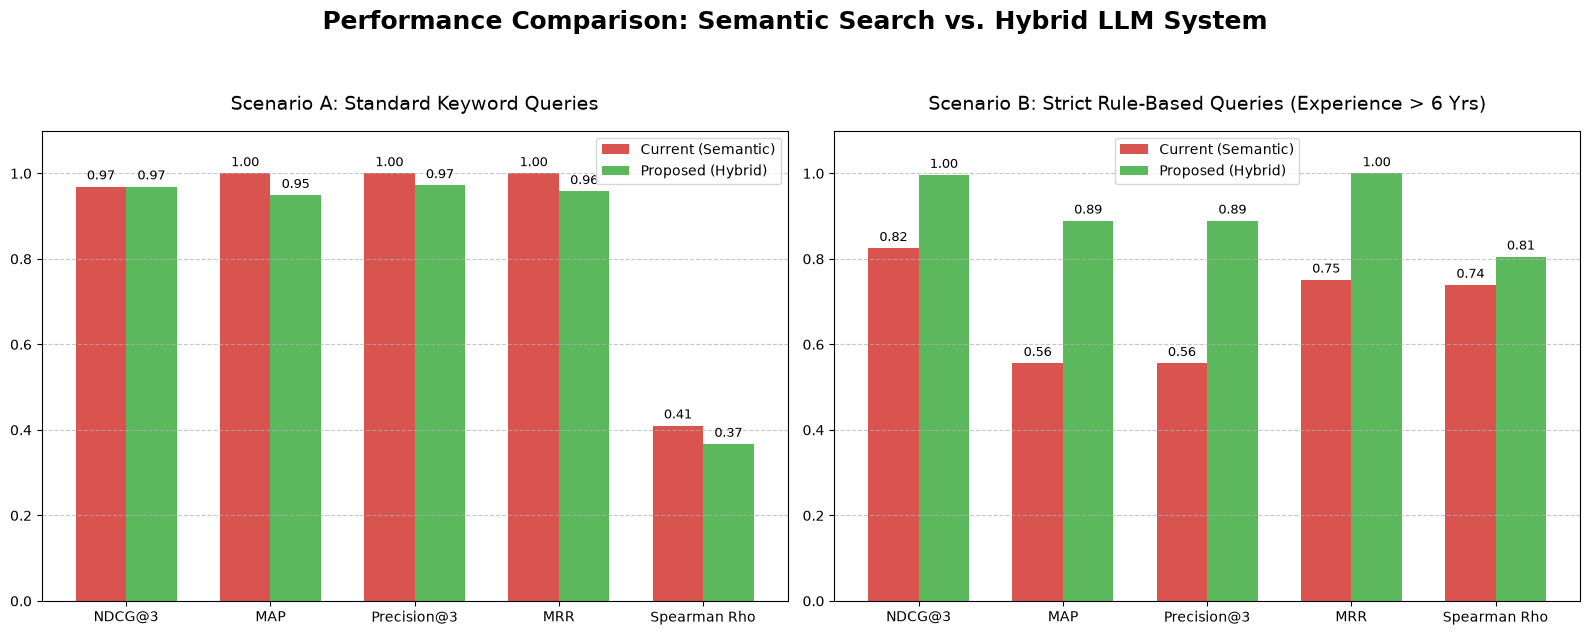

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define the Data (Using your exact final metrics) ---
metrics = ['NDCG@3', 'MAP', 'Precision@3', 'MRR', 'Spearman Rho']

# Scenario A: Lenient/Standard Queries
current_lenient = [0.969, 1.000, 1.000, 1.000, 0.410]
proposed_lenient = [0.969, 0.949, 0.972, 0.958, 0.367]

# Scenario B: Strict "Rule-Breaker" Queries
current_strict = [0.825, 0.556, 0.556, 0.751, 0.739]
proposed_strict = [0.996, 0.889, 0.889, 1.000, 0.805]

x = np.arange(len(metrics))
width = 0.35

# --- 2. Create the Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Scenario A (Lenient)
rects1_a = ax1.bar(x - width/2, current_lenient, width, label='Current (Semantic)', color='#d9534f')
rects2_a = ax1.bar(x + width/2, proposed_lenient, width, label='Proposed (Hybrid)', color='#5cb85c')
ax1.set_title('Scenario A: Standard Keyword Queries', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot Scenario B (Strict Rules)
rects1_b = ax2.bar(x - width/2, current_strict, width, label='Current (Semantic)', color='#d9534f')
rects2_b = ax2.bar(x + width/2, proposed_strict, width, label='Proposed (Hybrid)', color='#5cb85c')
ax2.set_title('Scenario B: Strict Rule-Based Queries (Experience > 6 Yrs)', fontsize=14, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels to bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1_a, ax1)
autolabel(rects2_a, ax1)
autolabel(rects1_b, ax2)
autolabel(rects2_b, ax2)

plt.suptitle('Performance Comparison: Semantic Search vs. Hybrid LLM System', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()